# Developing a Heart Disease Prediction Model (UCI Heart Disease Dataset)
# Author: Scott Szewczyk

# Introduction

**In this document, we develop and evaluate machine learning models for predicting the presence of heart disease with the UCI Heart Disease dataset.** Our assumption is that failing to identify patients with heart disease is more detrimental than referring patients who do not actually have heart disease for further testing. Therefore, we use recall as the primary target metric and precision as a secondary metric.

We begin by examining the quality of the data and conducting an exploratory data analysis (EDA). Then, we construct preprocessing pipelines to prevent information leakage during cross-validation. Next, we establish logistic regression and random forest models as baselines and use nested cross-validation to tune their hyperparameters. 

We then compare the four models (two baseline models and two tuned models) using recall, precision, ROC-AUC, and train-validation performance gaps. Finally, after recommending a model, we examine model coefficient interpretations, decision-threshold behavior, subgroup performance, and probability calibration. We also illustrate a cost-based framework for decision threshold selection, which future analyses can adapt once stakeholders fully define the relative costs of false negatives and false positives.

At this stage, the results lead us to suggest the **baseline logistic regression model**. Although the tuned models achieve slightly higher mean validation recall, the differences are not statistically distinguishable. Additionally, the baseline logistic regression has comparable precision and ROC-AUC to the other models, while showing little evidence of overfitting. However, due to the small sample sizes of predictor variable subgroups, there are likely to be substantial differences in performance between them. For example, we demonstrate that the model performs much worse on females than males in the test data. As a result, we cannot confidently recommend the model to be deployed across all patient subgroups. Our final recommendations, therefore, emphasize additional representative data collection and gathering stakeholder-defined operating requirements instead of moving directly towards clinical deployment.

---
# Data
We will use the UCI Heart Disease dataset, which combines anonymized patient records from four institutions: Cleveland, Hungary, VA Long Beach, and Switzerland. The dataset contains demographic information, clinical measurements, and a diagnosis of heart disease.

The original dataset and additional documentation are available through the UCI Machine Learning Repository. Additionally, script that the author of this document used to preprocess the data can be provided upon request.

# Permission
According to UCI, "This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license. This allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given."

# Acknowledgements
According to UCI, the database authors requested "that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. They would be:
1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D."

# Use of AI Tools
AI tools (GPT Luna-5.6 and Claude Sonnet 5) were used as supplementary aids for conceptual clarification, code creation and review, and editing. All analysis was independently reviewed and determined by the author.

---

# Variables

This dataset contains the following variables.

- **id**: Patient identification number
- **age**: Age of the patient in years
- **location**: Institution from which the observation originated
- **sex**: Sex of patient (Male/Female)
- **cp**: Chest pain type (Typical Angina/Atypical Angina/Non-Anginal Pain/Asymptomatic)
- **trestbps**" Resting blood pressure on admission to hospital (in mmHg)
- **chol**: Serum cholesterol (in mg/dl)
- **fbs**: Whether fasting blood sugar is greater than 120 mg/dl
- **restecg**: Resting electrocardiographic results (Normal/ST-T Wave Abnormality/Left Ventricular Hypertrophy)
- **thalach**: Maximum heart rate achieved
- **exang**: Whether a patient demonstrates exercise-induced angina
- **oldpeak**: ST depression induced by exercise, relative to rest
- **slope**: Slope of the peak exercise ST segment
- **ca**: Number of major vessels (0-3) colored by fluoroscopy
- **thal**: normal/fixed defect/reversible defect
- **num**: Patient's heart disease diagnosis (0 = no heart disease; values 1-4 = different types of heart disease)

# Target Variable
The goal of this document is to develop an initial model for binary heart disease prediction. Since our goal is to predict the mere presence of heart disease rather than a specific type, we will create a binary target variable, **hd**, from the variable num.

# Data Preprocessing

The preprocessing stage includes data cleaning, examination of missing and implausible values, and EDA.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import friedmanchisquare

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    PrecisionRecallDisplay,
    precision_score,
    recall_score  
)
from sklearn.model_selection import (
    cross_val_predict,
    cross_validate,
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler 

## Data Cleaning

In [2]:
# Set random seed for the document.
seed = 100

In [3]:
# Import UCI heart disease dataset.
heart = pd.read_csv('../data/heart_disease_uci.csv')
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalach   865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  location  920 non-null    object 
dtypes: float64(7), int64(2), object(6)
memory usage: 107.9+ KB


In [4]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,location
0,63,Male,Typical Angina,145.0,233.0,True,Left Ventricular Hypertrophy,150.0,False,2.3,3.0,0.0,6.0,0,Cleveland
1,67,Male,Asymptomatic,160.0,286.0,False,Left Ventricular Hypertrophy,108.0,True,1.5,2.0,3.0,3.0,2,Cleveland
2,67,Male,Asymptomatic,120.0,229.0,False,Left Ventricular Hypertrophy,129.0,True,2.6,2.0,2.0,7.0,1,Cleveland
3,37,Male,Non-Anginal Pain,130.0,250.0,False,Normal,187.0,False,3.5,3.0,0.0,3.0,0,Cleveland
4,41,Female,Atypical Angina,130.0,204.0,False,Left Ventricular Hypertrophy,172.0,False,1.4,1.0,0.0,3.0,0,Cleveland


First, we will make some simple adjustments to the dataset, dropping unneccessary columns and converting the heart disease variable **num** to a binary record of whether a patient has heart disease. 

In [5]:
# Drop the 'id' and 'location' columns.
heart.drop('location', axis = 1, inplace = True)

# Rename the 'num' column to 'hd' (for 'heart disease').
heart.rename(columns = {'num': 'hd'}, inplace = True)

# Convert the 'hd' column to binary.
heart['hd'] = np.where(heart['hd'] == 0, 0, 1)

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,63,Male,Typical Angina,145.0,233.0,True,Left Ventricular Hypertrophy,150.0,False,2.3,3.0,0.0,6.0,0
1,67,Male,Asymptomatic,160.0,286.0,False,Left Ventricular Hypertrophy,108.0,True,1.5,2.0,3.0,3.0,1
2,67,Male,Asymptomatic,120.0,229.0,False,Left Ventricular Hypertrophy,129.0,True,2.6,2.0,2.0,7.0,1
3,37,Male,Non-Anginal Pain,130.0,250.0,False,Normal,187.0,False,3.5,3.0,0.0,3.0,0
4,41,Female,Atypical Angina,130.0,204.0,False,Left Ventricular Hypertrophy,172.0,False,1.4,1.0,0.0,3.0,0


In [6]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalach   865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  hd        920 non-null    int64  
dtypes: float64(7), int64(2), object(5)
memory usage: 100.8+ KB


The dataset has 920 observations. Several columns, however, have a large number of null entries:

In [7]:
heart.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
hd            0
dtype: int64

Three variables -- slope, ca, and thal -- have more than 300 missing values, with ca and thal missing values for more than half of the observations. To this author's knowledge, the reasons for these missing values were not documented by UCI. Performing imputation on such sparse data would require making strong assumptions about their underlying distributions. Therefore, we will drop these columns going forward.

In [8]:
heart.drop(['slope', 'ca', 'thal'], axis = 1, inplace = True)

The rest of the columns have records for more than 90% of the participants, so we will perform imputations on the missing values. However, to avoid data leakage, we will do this after splitting the data into training and testing sets. Specifically, we will perform imputations during cross-validation.

In [9]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalach   865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  hd        920 non-null    int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 79.2+ KB


After dropping these columns, we are left with 10 variables that can be used for features, with **hd** being our target variable. 

Next, we will separate the numeric and categorical variables, as they will require different analyses and imputation techniques. 

In [10]:
# Create a column index of the numeric features.
numeric_cols = heart.select_dtypes(include = np.number).drop(columns = ['hd']).columns

# Create a column index of the categorical features.
categorical_cols = heart.select_dtypes(exclude = np.number).columns

## Univariate EDA

### Target variable

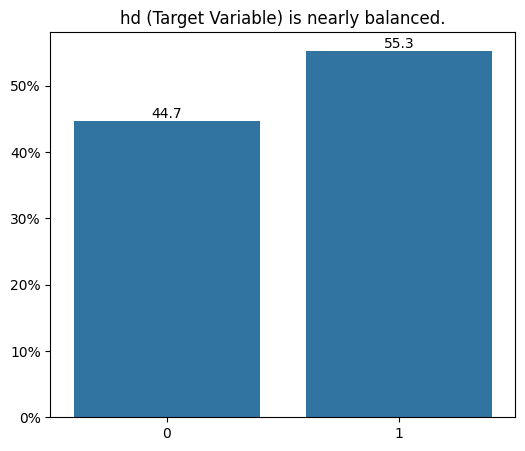

In [11]:
# Create a bar graph of hd's class distribution.
fig, ax = plt.subplots(figsize=(6, 5))
    
sns.countplot(data = heart, x = 'hd', stat = 'percent')

ax.bar_label(ax.containers[0], fmt ='%.1f')
plt.title(f"hd (Target Variable) is nearly balanced.")
ax.set(xlabel = None, ylabel = None)
ax.yaxis.set_major_formatter('{x:.0f}%')

plt.show()

The target variable hd is nearly balanced between patients without (44.7%) and with (55.3%) heart disease. Therefore, we will not need to perform class balancing to this variable when training the models.

### Numeric features

Next, we will examine the numeric features **age, trestbps, chol, thalach,** and **oldpeak** and look for any anomalies.

In [12]:
heart[numeric_cols].describe()

,age,trestbps,chol,thalach,oldpeak
count,920.000000,861.000000,890.000000,865.000000,858.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788
std,9.424685,19.066070,110.780810,25.926276,1.091226
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,175.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000
75%,60.000000,140.000000,268.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


<Axes: >

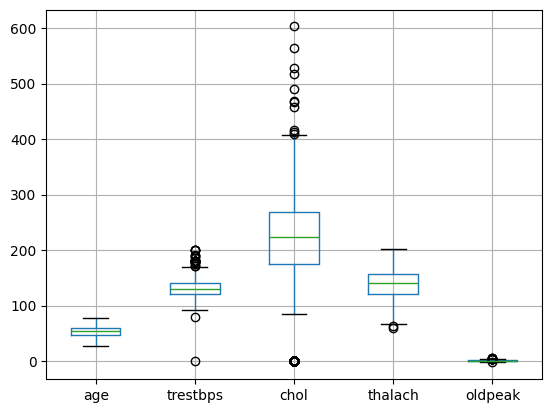

In [13]:
heart[numeric_cols].boxplot()

First, we can see that the numeric variables have very different ranges. For example, **oldpeak** is centered near zero with single-digit values, while **chol** is centered above 200 with a standard deviation of over 100. As a result, for the logistic regression models, we will need to rescale the numeric variables before training the models so the larger variables do not conceal potential influences from the smaller variables.

---

Next, we will evaluate whether each numeric variable has acceptable values. We will refer to the feature definitions from Yazdani et al. (2021) as a guide for determining acceptable values for the variables, investigating values that are very high and very low for each variable.

#### age
**age** ranges from 28 to 77 years, with a median of 54 years and no outliers. These values are all appropriate for a study on adults. We will leave age as a continuous variable in this document, but it may make sense to consider converting it to a binned categorical variable in future work. No corrections are needed.

#### trestbps
**trestbps** (resting blood pressure in mmHg) ranges mostly from approximately 100 to 200. Yazdani et al. defines the lowest value for this variable as 90 (in the "normal" range) and the highest values as being above 160 (the "very high" range). The summary statistics show that that highest value in this dataset is 200. Yazadi et al. does not explicitly define upper limits for trestbps, but "Things you need to know..." (2006) suggests that blood pressures of 200 mmHg are possible, so we will consider all of the higher trestbps values to be plausible.

We will investigate the trestbps values below Yazdani's range, however (< 90 mmHg).

In [14]:
heart[heart['trestbps'] < 90]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,hd
630,55,Male,Non-Anginal Pain,0.0,0.0,False,Normal,155.0,False,1.5,1
844,53,Male,Asymptomatic,80.0,0.0,NaN,Normal,141.0,True,2.0,0


There are two entries with trestbps below 90: one with 80 mmHg and one with 0 mmHg. 80 mmHg is close enough to the defined range that we will consider it plausible. 0 mmHg, on the other hand, is not. It is likely that 0 mmHg refers to missing data, so we will replace this value with NaN.

In [15]:
# Replace trestbps values of 0 with NaN.
heart['trestbps'] = np.where(heart['trestbps'] == 0, np.nan, heart['trestbps'])

#### chol
**chol** (serum cholesterol in mg/dl) ranges mostly from 100 to 400, with some low and high outliers. Yazdani et al. defines the lowest value as 110 (in the "normal" range) and the highest values as being above 250 (the "very high" range). 

Yazdani et al. does not define an upper limit for cholesterol, but Richards (2022) suggests that values into the 800s, though rare, are possible. Therefore, since chol in this dataset only reaches as high as the 600s, we will consider the upper outliers to be plausible.  

The lower chol values, on the other hand, reveal some problems with the data.

In [16]:
heart[heart['chol'] < 110].sort_values('chol', ascending = False)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,hd
431,52,Male,Atypical Angina,140.0,100.0,False,Normal,138.0,True,0.0,0
625,56,Male,Asymptomatic,120.0,100.0,False,Normal,120.0,True,1.5,1
473,56,Male,Asymptomatic,120.0,85.0,False,Normal,140.0,False,0.0,0
917,72,Male,Non-Anginal Pain,160.0,0.0,NaN,Left Ventricular Hypertrophy,114.0,False,1.6,0
864,57,Male,Asymptomatic,160.0,0.0,NaN,Normal,98.0,True,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...
805,38,Male,Asymptomatic,135.0,0.0,NaN,Normal,150.0,False,0.0,1
806,38,Male,Asymptomatic,150.0,0.0,NaN,Normal,120.0,True,NaN,1
807,40,Male,Asymptomatic,95.0,0.0,NaN,ST-T Wave Abnormality,144.0,False,0.0,1
808,41,Male,Asymptomatic,125.0,0.0,NaN,Normal,176.0,False,1.6,1


In [17]:
print(f"There are {len(heart[heart['chol'] == 0])} rows with a chol of 0.") 

There are 172 rows with a chol of 0.


There are a few chol values below, but near, 110, so we will consider those plausible. Most of the low chol values are 0, though, which is not plausible. These values almost certainly represent missing data, so we will replace these values with NaN.

In [18]:
# Replace chol values of 0 with NaN.
heart['chol'] = np.where(heart['chol'] == 0, np.nan, heart['chol'])

#### thalach
**thalach** (maximum heart rate) ranges from 60 to 202. Yazdani et al. defines 60-100 as "Normal" and above 100 as "Tachycardia." As before, Yazdani et al. does not define an upper limit for this variable, but Mass General Brigham suggests that a heart rate of 200 is possible. All values for this variable are plausible, so no corrections are needed.

#### oldpeak
**oldpeak** (ST depression induced by exercise relative to rest) ranges from -2.6 to 6.2. Yazdani et al. only defines oldpeak as capable of being 0 or positive. 

In [19]:
heart[heart['oldpeak'] < 0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,hd
602,66,Male,Non-Anginal Pain,120.0,NaN,False,ST-T Wave Abnormality,120.0,False,-0.5,0
803,38,Male,Non-Anginal Pain,100.0,NaN,NaN,Normal,179.0,False,-1.1,0
809,42,Male,Asymptomatic,105.0,NaN,NaN,Normal,128.0,True,-1.5,1
814,45,Male,Non-Anginal Pain,110.0,NaN,NaN,Normal,138.0,False,-0.1,0
815,46,Male,Asymptomatic,100.0,NaN,NaN,ST-T Wave Abnormality,133.0,False,-2.6,1
829,51,Male,Asymptomatic,130.0,NaN,NaN,Normal,170.0,False,-0.7,1
853,56,Male,Non-Anginal Pain,125.0,NaN,NaN,Normal,98.0,False,-2.0,1
855,56,Male,Asymptomatic,115.0,NaN,NaN,ST-T Wave Abnormality,82.0,False,-1.0,1
856,56,Male,Asymptomatic,120.0,NaN,False,ST-T Wave Abnormality,100.0,True,-1.0,1
891,62,Male,Typical Angina,120.0,NaN,NaN,Left Ventricular Hypertrophy,134.0,False,-0.8,1


All of the negative oldpeak values are within the range of the positive values (i.e. 0 to 6.2), so it is possible that these values had negative signs mistakenly included. However, we will refrain from making that assumption for this document and simply replace the negative values with NaN.

In [20]:
# Replace negative oldpeak values with NaN.
heart['oldpeak'] = np.where(heart['oldpeak'] < 0, np.nan, heart['oldpeak'])

### Categorical features

Next we will visualize the distributions of the categorical features **sex**, **cp**, **fbs**, **restecg**, and **exang**.

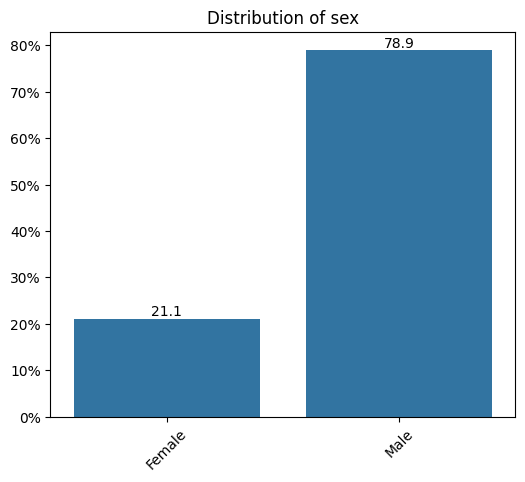

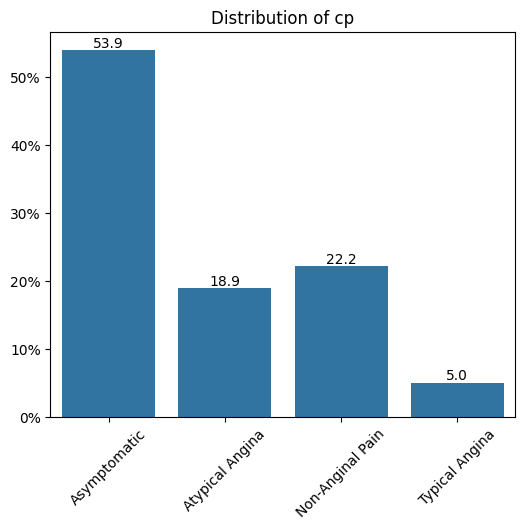

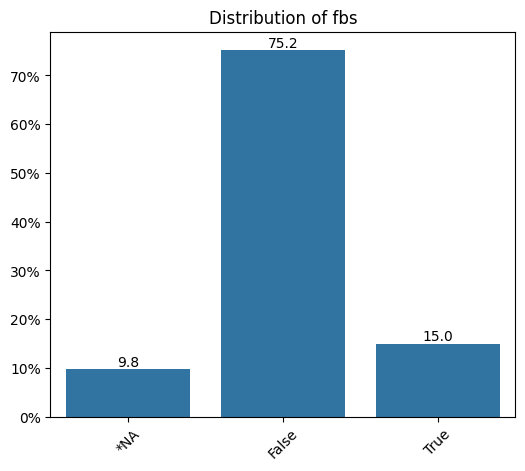

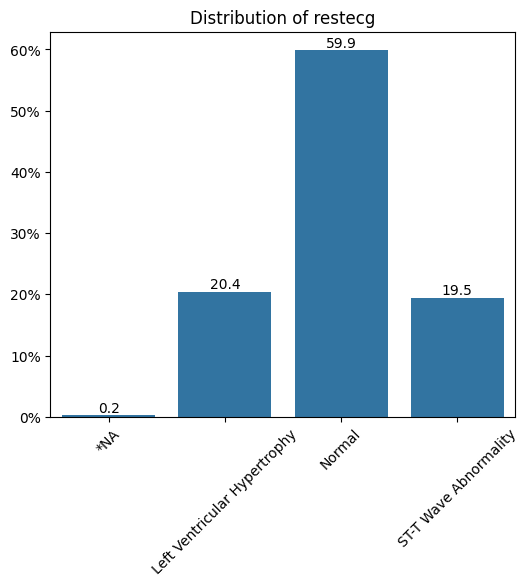

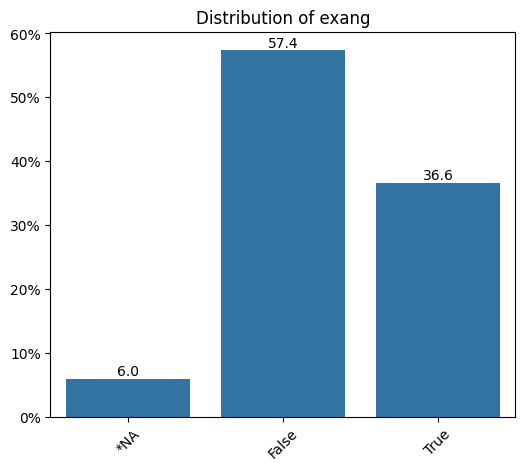

In [21]:
# Create a barplot of the distribution of each categorical feature.

for col in categorical_cols:
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    sns.countplot(data = heart[categorical_cols].fillna('*NA').astype('str'), x = col,
                  stat = 'percent', order = np.sort(heart[categorical_cols].fillna('*NA')[col].astype('str').unique())) 

    ax.bar_label(ax.containers[0], fmt ='%.1f')

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    ax.set(xlabel = None, ylabel = None)
    ax.yaxis.set_major_formatter('{x:.0f}%')
    plt.show()

#### sex

There is a large class imbalance for sex. Males outnumber females by a factor of almost 4:1.

#### cp

There are large class imbalances for cp (chest pain type). Asymptomatic cases outnumber Atypical Angina and Non-Anginal Pain by a factor of about 2.5:1 and Typical Angina by a factor of almost 11:1. Atypical Angina and Non-Anginal cases both make up about 20% of cases. Typical angina is sparsely represented in the data, making up only 5% of cases.

#### fbs

There is a large class imbalance for fbs (whether fasting blood sugar is above 120 mg/dl). Those with low fbs (fbs = False) outnumber those with high fbs by a factor of about 5:1. About 10% of the participants are missing fbs values.

#### restecg

There is a large class imbalance between Normal restecg (resting electrocardiographic results) values and the other levels. Normal restecg values outnumber the other classes by a factor of 3:1. Left Ventricular Hypertrophy and ST-T Wave Abnormality each comprise about 20% of the restecg values.

#### exang

There is a moderate class imbalance for exang (exercise-induced angina). Cases without exercise-induced angina (exang = False) outnumber those with exercise-induced angina by about 20 percentage points.

___
**The most striking pattern of the categorical features, except arguably exang, is that they show major class imbalances. Although  class imbalances, per se, in feature variables will not harm the predictive quality of the model, the fact that some classes have so few observations (e.g. there are only 46 observations of Typical Angina chest pain) means that the model will not be able to learn as much about them. Later on, we will note how the small subgroup sizes may impact the effectiveness of the models.**

## Bivariate EDA

### Numeric features

Next, we will look at the distributions of the numeric features, conditional on the target variable hd.

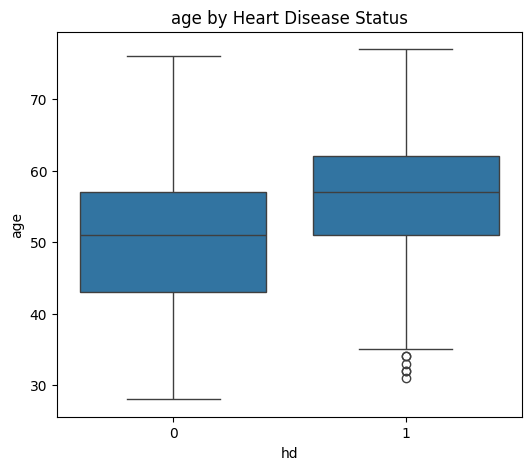


Summary statistics for age:
           count       mean       std   min   25%   50%   75%   max
No HD (0)  411.0  50.547445  9.433700  28.0  43.0  51.0  57.0  76.0
HD (1)     509.0  55.903733  8.718959  31.0  51.0  57.0  62.0  77.0
------------------------------------------------------------
------------------------------------------------------------
------------------------------------------------------------


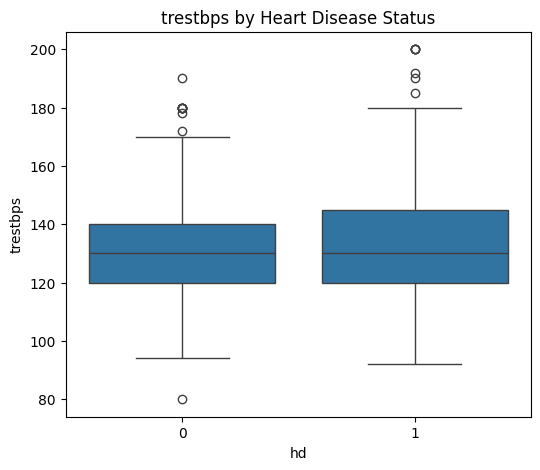


Summary statistics for trestbps:
           count        mean        std   min    25%    50%    75%    max
No HD (0)  391.0  129.913043  16.869867  80.0  120.0  130.0  140.0  190.0
HD (1)     469.0  134.264392  19.617889  92.0  120.0  130.0  145.0  200.0
------------------------------------------------------------
------------------------------------------------------------
------------------------------------------------------------


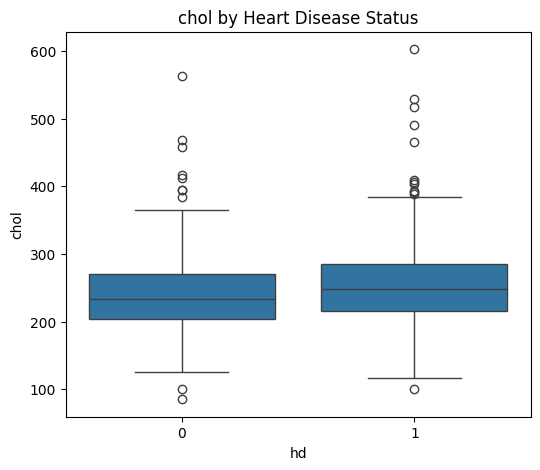


Summary statistics for chol:
           count        mean        std    min    25%    50%     75%    max
No HD (0)  372.0  240.158602  55.767559   85.0  204.0  233.0  270.25  564.0
HD (1)     346.0  254.008671  60.620439  100.0  216.0  248.0  284.75  603.0
------------------------------------------------------------
------------------------------------------------------------
------------------------------------------------------------


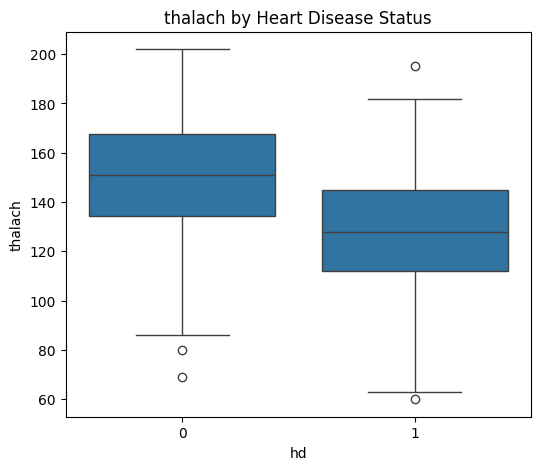


Summary statistics for thalach:
           count        mean        std   min    25%    50%    75%    max
No HD (0)  391.0  148.800512  23.608692  69.0  134.5  151.0  167.5  202.0
HD (1)     474.0  128.261603  24.024193  60.0  112.0  128.0  145.0  195.0
------------------------------------------------------------
------------------------------------------------------------
------------------------------------------------------------


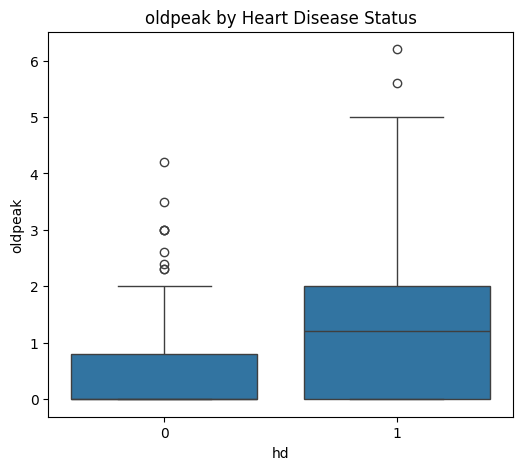


Summary statistics for oldpeak:
           count      mean       std  min  25%  50%  75%  max
No HD (0)  387.0  0.425840  0.712184  0.0  0.0  0.0  0.8  4.2
HD (1)     459.0  1.311329  1.153295  0.0  0.0  1.2  2.0  6.2
------------------------------------------------------------
------------------------------------------------------------
------------------------------------------------------------


In [22]:
# Create boxplots and summary tables for each numeric feature,
# conditional on the value of the target variable hd.
for col in numeric_cols:
    fig, ax = plt.subplots(figsize = (6, 5))
    sns.boxplot(data = heart, x = 'hd', y = col, ax = ax)
    ax.set_title(f'{col} by Heart Disease Status')
    plt.show()

    summary = heart.groupby('hd')[col].describe()
    summary.index = ['No HD (0)', 'HD (1)']
    print(f"\nSummary statistics for {col}:")
    print(summary)
    print("-" * 60)
    print("-" * 60)
    print("-" * 60)

#### age | hd

People with heart disease (hd = 1), have a slightly higher age distribution than those without (hd = 0). Those with heart disease have a median age 6 years higher than those without heart disease. The range and standard deviation of age is similar for both groups.

#### trestbps | hd

The distributions of trestbps (resting blood pressure in mmHg) have similar distributions, with identical Q1s (120) and medians (130), standard deviations within 3 mmHg of each other, and similar ranges.

#### chol | hd

People with heart disease have a slightly higher chol (serum cholesterol in mg/dl) distribution than those without. Those with heart disease have a median chol 15 mg/dl higher than those without. The groups have comparable ranges and standard deviations.

#### thalach | hd

People with heart disease have a distinctly lower thalach (maximum heart rate) distribution than those without. Based on the values of Q1, median, and Q3, the distribution for those with heart disease is essentially, the the no-heart-disease distribution shifted down by about 22-23 beats per minute. The two distributions have similar ranges and standard deviations.

#### oldpeak | hd

People with heart disease have a clearly higher and more variable oldpeak (ST depression induced by exercise relative to rest) distribution than those without. For example, the median oldpeak for those without heart disease is 0, while the median for those with heart disease is 1.2. The distribution for those with heart disease has a larger range and standard deviation than for those without.

---
**Of all the numeric features, thalach and oldpeak have the largest differences between patients with and without heart disease. These two variables, therefore, appear potentially informative for prediction.**

#### Feature correlations

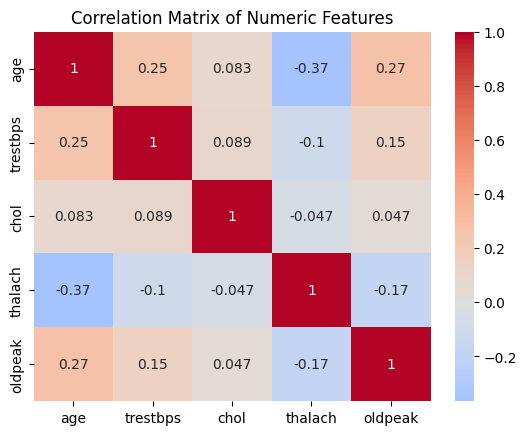

In [23]:
sns.heatmap(heart[numeric_cols].corr(), annot = True, cmap = 'coolwarm', center = 0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

Most of the pairwise correlations are rather small, with 6 out of the 9 correlations being no larger than 0.1 (in terms of absolute value). The variable age has the three largest correlations: -0.37 with thalach, 0.27 with oldpeak, and 0.15 with trestbps. These correlations are not extremely large, though, so they do not indicate a severe multicollinearity risk. However, it is possible that the age-thalach and age-oldpeak correlations might introduce some uncertainty into individual coefficient estimates but will not impact the model's predictive fit (Vatcheva et al., 2016). Regardless, the primary purpose of the analysis, at this stage, is prediction rather than causal inference, so we will retain these variables.

### Categorical features

Next, we will look at the heart disease rates for each categorical feature.

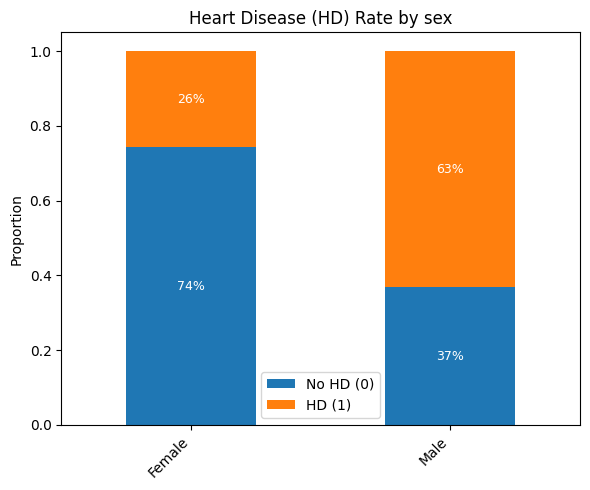

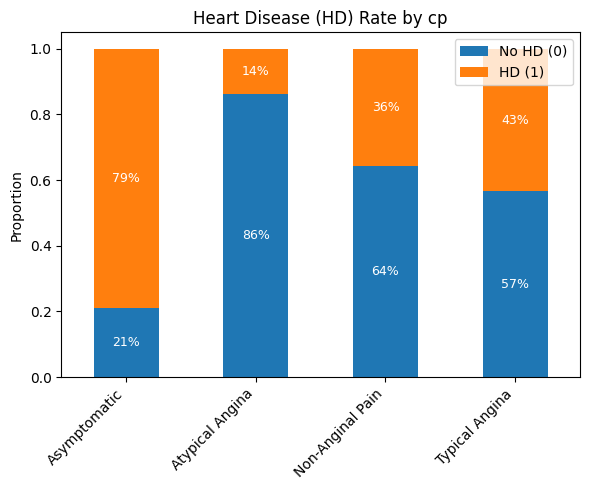

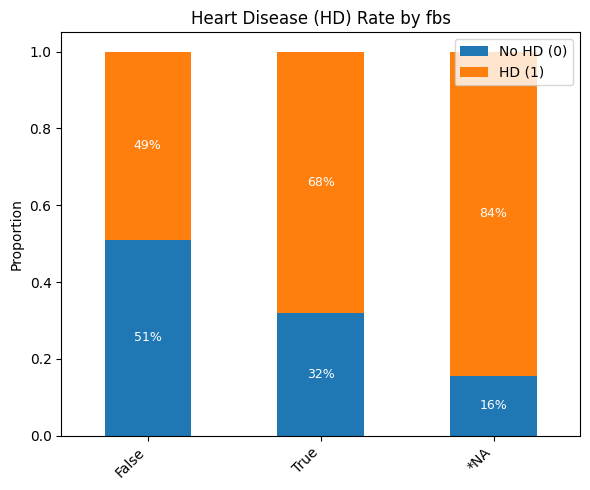

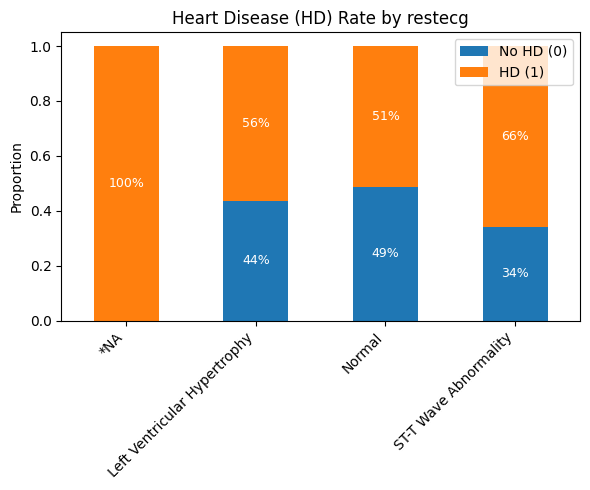

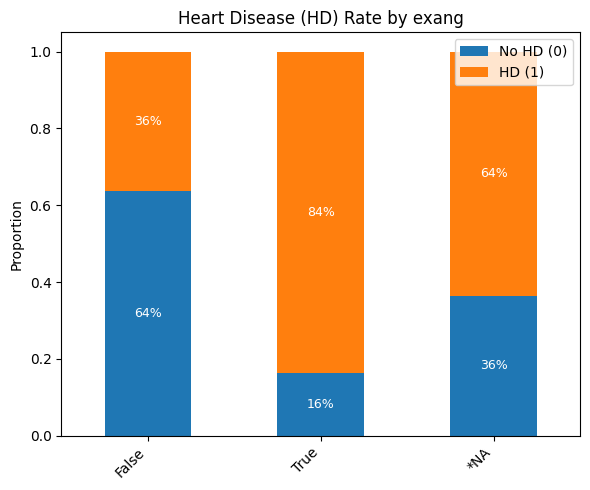

In [24]:
# Create stacked barplots of the differential heart disease rates of each categorical variable.
for col in categorical_cols:
    
    col_data = heart[col].fillna('*NA')

    ct = pd.crosstab(col_data, heart['hd'], normalize='index')

    fig, ax = plt.subplots(figsize = (6, 5))
    ct.plot(kind = 'bar', stacked = True, ax = ax)

    # Add % labels to each segment of each bar.
    for container in ax.containers:
        labels = [f'{v:.0%}' if v > 0.03 else '' for v in container.datavalues]
        ax.bar_label(container, labels = labels, label_type = 'center', fontsize = 9, color = 'white')

    ax.set_title(f'Heart Disease (HD) Rate by {col}')
    ax.set_ylabel('Proportion')
    ax.set_xlabel(None)
    plt.xticks(rotation = 45, ha = 'right')
    plt.legend(title = '', labels = ['No HD (0)', 'HD (1)'])
    plt.tight_layout()
    plt.show()

#### hd | sex

There is a massive sex gap in heart disease rate. Males have a heart disease rate that is almost 2.5 times that of females.

#### hd | cp

The heart disease rate varies widely for each category of cp (chest pain type). The Asymptomatic has, by far, the highest heart disease rate, followed by Typical Angina, Non-Anginal Pain, then Atypical Angina.

#### hd | fbs

The heart disease rate is distinctly higher for those with fasting blood sugar above 120 mg/dl (fbs = True) than for those below 120 mg/dl. It is also worth noting that 84% of the 90 missing fbs values have heart disease.

#### hd | restecg

The differences between Normal and Left Ventricular Hypertrophy restecg (resting electrocardiographic results) are modest, but those with ST-T Wave Abnormality have a 10-15 percentage point higher rate of heart disease than the other two groups. There are only 2 missing values in this column, so the fact that 100% of this group has heart disease is not meaningful.

#### hd | exang

There is a massive gap in heart disease rate between the exang (exercise-induced angina) groups. Those with exercise-induced angina have a heart disease rate about 2.3 times that of those without exercise-induced angina. The 55 null values have a heart disease rate between that of the other two groups.

---
**Each categorical variable, except perhaps restecg, has large differences in heart disease rates among its respective subgroups. The fact that heart disease rates vary so widely within each variable means that the categorical variables have potential to be strong predictors of heart disease.**

# Model Preparation

Before fitting the models, we will separate the predictors from the target variable and construct preprocessing pipelines for numeric and categorical variables. Then, we will split the data into training and test sets before model fitting, preserving the target variable distribution through stratification.

To avoid data leakage, we incorporate all transformations that estimate values from the data into the modeling pipeline so that they are learned separately within each cross-validation training fold.

### Train-test Split

We will use a 70%-30% train-test split on the dataset, stratifying on the response variable **hd**.

In [25]:
# Create the feature DataFrame X.
X = heart.drop(columns = 'hd')

# Create the response DataFrame y.
y = heart['hd']

# Split the data using a 70-30 train-test split, stratifying on the response y.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3,
                                                    stratify = y, random_state = seed)

print('Training features dimensions:', X_train.shape)
print('Test features dimensions:', X_test.shape)
print('')
print('Training response dimensions:', y_train.shape)
print('Test response dimensions:', y_test.shape)

Training features dimensions: (644, 10)
Test features dimensions: (276, 10)

Training response dimensions: (644,)
Test response dimensions: (276,)


In [26]:
y_train.value_counts(normalize = True)

hd
1    0.552795
0    0.447205
Name: proportion, dtype: float64

In [27]:
y_test.value_counts(normalize = True)

hd
1    0.554348
0    0.445652
Name: proportion, dtype: float64

The training and testing responses both preserve the original dataset's 55%-45% distribution.

### Data Imputation

As mentioned above, we will need to impute data for the missing values in the feature columns.
- For the **numeric** features, we will impute the **medians** of each column.
- For the **categorical** features, we will impute **randomly sampled values from the observed class distribution of each feature**. For example, if a categorical feature with classes A, B, and C is 50% A, 30% B, and 20% C, then each missing value will have a 50% chance of having A imputed, a 30% of having B imputed, and a 20% chance of having C imputed.

**To prevent data leakage in cross-validation, we need to incorporate these imputation procedures into the model pipeline. Otherwise, information from validation folds could affect the imputations used to train the model, potentially leading to overfitting**.

We will use K-Fold cross-validation from the scikit-learn library, so we can use the SimpleImputer() class to impute medians for the numeric features. As of this writing, however, it does not appear that scikit-learn has an established class for performing our desired imputation for the categorical features. Therefore, we will need to create a custom class for this task.

#### Custom Categorical Imputer: RandomCategoryImputer()
We will define the class RandomCategoryImputer() to work in scikit-learn pipelines.

**RandomCategoryImputer() imputes random values into missing cells of categorical features according to the class proportions of each column.** The imputer does this by calculating the class proportions of each column, then randomly sampling from the class distribution of each column and imputing the sampled values into the missing cells.

**We are writing this script so that the class proportions are calculated separately <u>within each training fold</u>. The imputer, therefore, does not use information from validation folds to determine how the missing values should be filled**.

In [28]:
# Define the class RandomCategoryImputer() to use in scikit-learn pipleines.

# NOTE: RandomCategoryImputer() requires the following libraries:
## import pandas as pd
## import numpy as np
## from sklearn.base import BaseEstimator, TransformerMixin

class RandomCategoryImputer(BaseEstimator, TransformerMixin):

    # Initialize the imputer.
    def __init__(self, random_state = 100):

    # Random state is set for the sake of reproducability.
        self.random_state = random_state

    # Compute the class proportions for each column.
    def fit(self, X, y = None):

        X = pd.DataFrame(X)
        self.distributions_ = {}

        for col in X.columns:
            self.distributions_[col] = X[col].value_counts(normalize = True)

        return self

    # Sample random values according to the class proportions of each column
    # and impute these values into the missing cells.
    def transform(self, X):

        X = pd.DataFrame(X).copy()
        rng = np.random.default_rng(self.random_state)

        for col in X.columns:

            mask = X[col].isna()

            if mask.any():

                probs = self.distributions_[col]

                X.loc[mask, col] = rng.choice(
                    probs.index,
                    size = mask.sum(),
                    p = probs.values
                )
                
        return X

    # Retrieve feature names from fitted models.
    def get_feature_names_out(self, input_features = None):
            
        return np.asarray(input_features)

### Preprocessing Pipeline

Now that we have our imputer classes, we can set up the preprocessing pipeline for scikit-learn.

The numeric predictors are median-imputed and standardized using StandardScaler(). Standardization is important for logistic regression because it places the numeric predictors on a common scale so that the variables with larger numerical distributions do not block out the influence of the other variables. Random forest models are not harmed by the presence of different scales, but we will use the same preprocessing pipeline for our random forest model so that we do not need to create an additional pipeline.

The categorical predictors are imputed using the custom categorical imputer and then converted to indicator variables using one-hot encoding.

The preprocessing steps are contained within the model pipeline so that they are refit independently during cross-validation.

In [29]:
# Define pipeline for numeric features. First, impute the median of each feature. Then, standardize each feature.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

# Define pipeline for categorical features. First, impute values with the custom imputer. Then, perform one-hot encoding.
categorical_pipeline = Pipeline([
    ("imputer", RandomCategoryImputer()),
    ("encoder", OneHotEncoder(drop = "first", handle_unknown = "ignore"))
])

# Define the preprocessor to apply separate functions to the numeric and categorical features.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Modeling

To predict heart disease, we will start with two baseline models: **logistic regression** and **random forest**. These are basic models that are commonly used for classification tasks and are heavily supported in scikit-learn. 

Additionally, these models have complementary approaches: logistic regression provides a relatively simple and interpretable linear decision boundary, while random forest can capture nonlinear relationships and interactions. Logistic regression has the added benefit of having interpretable coefficients, potentially allowing us to move toward a causal understanding in future analyses.

After fitting the baseline models, we will then try to improve on them by using nested cross-validation for hyperparameter tuning.

## Target Metrics

Since heart disease is a life-threatening condition, we want to be able to catch as many cases as is feasible, erring on the side of false positives. A false negative -- failing to identify a patient who has heart disease -- is potentially more damaging than a false positive -- referring a patient who does not actually have heart disease for further testing. Recall, which refers to the proportion of target cases that a model identifies, is the best metric for this goal. **In cross-validation, we will evaluate our models on their recall.**

Of course, if we wanted to maximize recall absolutely, we could simply classify every patient as having heart disease so they could be referred for further testing. However, this would not be practical in a clinical setting, so **we will also monitor precision** as we evaluate the models. 

- #### Primary metric: Recall 
    - Proportion of total heart disease cases identified.
    - Ex: If there are 100 patients with heart disease in the data and the model identifies 96 of them, then recall = 96%.
- #### Secondary metric: Precision 
    - Proportion of predicted heart disease cases that actually have heart disease.
    - Ex: If the model classifies 80 patients as having heart disease, but only 60 of them actually do, then precision = 75%

We will also report ROC-AUC as a tertiary metric to judge the models' discriminatory capabilities. ROC-AUC is a threshold-independent measure of the models' ability to discriminate between patients with and without heart disease.

## Baseline Models

We will start with two baseline models: 
- Logistic Regression
- Random Forest

Using the default hyperparameters from scikit-learn, we will use 5-fold cross-validation to estimate validation performance on the training data.

In [30]:
# Define baseline logistic regression pipeline.
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter = 1000))
])

# Define baseline random forest pipeline.
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state = seed))
])

<u>NOTE: When tuning our baseline models in the subsequent section, we will use nested cross-validation, which uses outer and inner folds. The outer fold will contain the final validation data that we will use to compare all of the models later on, so we will use the name "outer_cv" for the baseline and tuned models<u>.

In [31]:
# Conduct 5-fold cross validation for the Logistic Regression and Random Forest models.
# StratifiedKFold() preserves the class proportions for the response variable
# (i.e. each fold will have roughly the same proportions of positive heart disease cases).

# Define outer cross-validation folds (contains final validation folds for baseline and tuned models).
outer_cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = seed
)

# Define inner cross-validation folds (contains folds to choose hyperparameters for tuned models).
# NOTE: inner_cv is not needed for the baseline models. It will be used in the next section.
inner_cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = seed
)

baseline_logistic_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv = outer_cv,
    scoring = {
        "recall": "recall",
        "precision": "precision",
        "roc_auc": "roc_auc"
    },
    return_train_score = True
)

baseline_rf_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv = outer_cv,
    scoring = {
        "recall": "recall",
        "precision": "precision",
        "roc_auc": "roc_auc"
    },
    return_train_score = True
)

print("\nCross-Validated Recall\n")
print(f"Logistic Regression: {baseline_logistic_results['test_recall'].mean():.3f} ± {baseline_logistic_results['test_recall'].std():.3f}")
print(f"Random Forest: {baseline_rf_results['test_recall'].mean():.3f} ± {baseline_rf_results['test_recall'].std():.3f}")


Cross-Validated Recall

Logistic Regression: 0.820 ± 0.047
Random Forest: 0.817 ± 0.054


The baseline models perform similarly well. Logistic regression has a mean validation recall of 82.0% (SD = 4.7%), while random forest has a mean validation recall of 81.7% (SD = 5.4%). The difference between the mean recalls is small relative to the fold-to-fold variability.

## Hyperparameter Tuning: Nested Cross-validation

Next, we will evaluate whether tuning the hyperparameters can improve upon the baseline models. Since we are performing two tasks simultaneously, tuning the hyperparameters and evaluating the performance of the tuning process, we will need to use **nested cross-validation**. 

Non-nested cross-validation would be risky in this situation because it could lead to inflated estimates of the tuned models' performances. Brownlee (2021) notes that overfitting could arise because the models are evaluated and selected on the same data that they are trained on. Nested cross-validation is a solution to this issue because model performance is evaluated on different data than it was trained on.

Please note that, even though the nested cross-validation process tries out different hyperparameter values, this process, by itself, does not recommend specific hyperparameter configurations. Instead, what the nested cross-validation process give us is an estimate of the performance that the tuning process will lead to. It tells us how a potential model will perform, not what its exact hyperparameters will be. If the nested cross-validation process suggests that it can improve on the baseline models, then we will conduct an additional cross-validation phase to select the best hyperparameters.

We will again use five-fold cross-validation for both nesting levels, with recall as the target metric.

### Logistic Regression Tuning

We will vary the regularization parameter C across five different values.

In [32]:
# Define hyperparameter candidate values.
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

# Conduct hyperparameter tuning on inner folds.
logistic_grid_nested = GridSearchCV(
    estimator = logistic_pipeline,
    param_grid = logistic_param_grid,
    cv = inner_cv,
    scoring = "recall",
    n_jobs = -1
)

# Evaluate tuned models on outer folds.
tuned_logistic_results = cross_validate(
    logistic_grid_nested,
    X_train,
    y_train,
    cv = outer_cv,
    scoring = ["recall", "precision", "roc_auc"],
    return_train_score = True,
    n_jobs = -1
)

print(
    f"Tuned Logistic Regression CV recall: "
    f"{tuned_logistic_results['test_recall'].mean():.3f} "
    f"± {tuned_logistic_results['test_recall'].std():.3f}"
)

Tuned Logistic Regression CV recall: 0.829 ± 0.042


The nested cross-validation procedure on the logistic regression model yields a mean recall of 82.9% (SD = 4.2%). This mean is higher than that of either baseline model. 

### Random Forest Tuning

We will vary the following hyperparameters:
- Number of trees (estimators)
- Maximum tree depth
- Minimum number of samples per split

In [33]:
# Define hyperparameter candidate values.

rf_param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

# Conduct hyperparameter tuning on inner folds.
rf_grid_nested = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = rf_param_grid,
    scoring = "recall",
    cv = inner_cv,
    n_jobs = -1,
    refit = True
)

# Evaluate tuned models on outer folds.
tuned_rf_results = cross_validate(
    rf_grid_nested,
    X_train,
    y_train,
    cv = outer_cv,
    scoring = ["recall", "precision", "roc_auc"],
    return_train_score = True,
    n_jobs = -1
)

print(
    f"Tuned Random Forest CV recall: "
    f"{tuned_rf_results['test_recall'].mean():.3f} "
    f"± {tuned_rf_results['test_recall'].std():.3f}"
)

Tuned Random Forest CV recall: 0.840 ± 0.038


The nested cross-validation procedure on the random forest model yields a mean recall of 84.0% (SD = 3.8%). This mean is the highest of any model so far.

# Model Comparisons

We will now compare the four models, the two baseline models and two tuned models, using their performances on the out-of-fold (validation) data. Even though the models had different point estimates for mean recall, we will evaluate whether these differences are statistically significant by visually comparing their distributions and using statistical testing. Additionally, we will consider each model's overfitting risk.

Recall is the primary criterion for model comparison, but we, as noted, will still track precision and ROC-AUC as additional evaluation criteria.

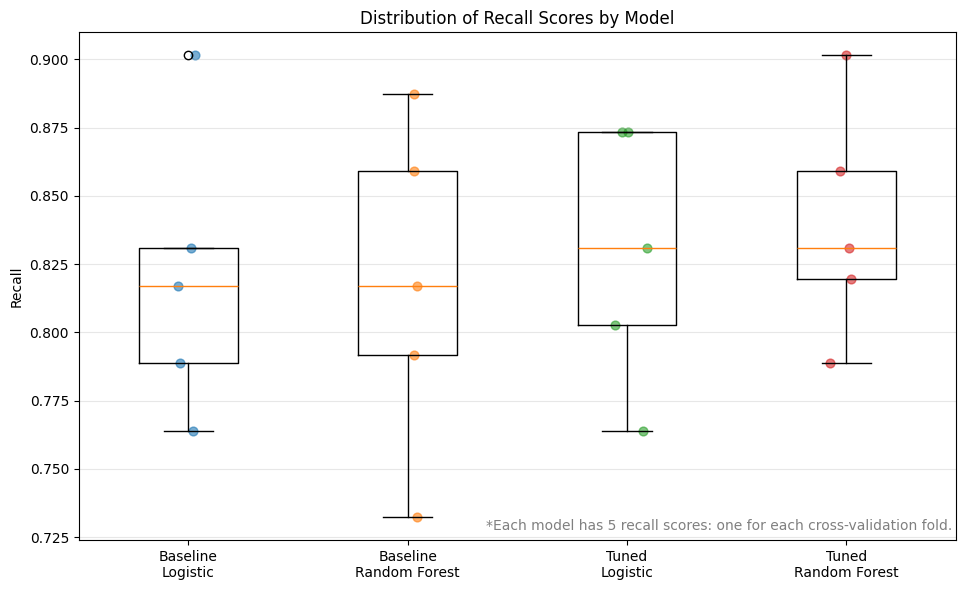

In [34]:
# Create visualization of recall distributions for each model.

score_list = [
    baseline_logistic_results['test_recall'],
    baseline_rf_results['test_recall'],
    tuned_logistic_results['test_recall'],
    tuned_rf_results['test_recall']
]

labels = [
    "Baseline\nLogistic",
    "Baseline\nRandom Forest",
    "Tuned\nLogistic",
    "Tuned\nRandom Forest"
]

plt.figure(figsize = (10, 6))

plt.boxplot(score_list, labels = labels)

rng = np.random.default_rng(seed)

for i, vals in enumerate(score_list, start = 1):
    x = rng.normal(i, 0.04, len(vals))
    plt.scatter(x, vals, alpha = 0.6, s = 40)

plt.ylabel("Recall")
plt.title("Distribution of Recall Scores by Model")

plt.text(0.73, 0.02, "*Each model has 5 recall scores: one for each cross-validation fold.", 
         ha = 'center', 
         transform = plt.gca().transAxes,
         color='gray')

plt.grid(axis = "y", alpha = 0.3)
plt.tight_layout()
plt.show()

There is considerable overlap among the recall distributions. A basic visual inspection suggests that there are likely no significant differences in recall performance among the four models. If there are significant differences, they are likely to be small. In the next section, we will use statistical tests to evaluate this claim.

It is worth noting, however, that the worst recall scores of the tuned models are both higher than their baseline counterparts. This could mean that, with more data, these models may become more consistent or "safe" than the baseline models. However, more data is needed to test this theory.

### Statistical testing: comparing the four models

As mentioned above, visual inspection suggests substantial overlap in the recall performance of the four models. We will now evaluate this claim with statistical testing.

According to the framework outlined by Rainio, et al. (2024), we can use Friedman's test to compare sensitivity (i.e. recall) across more than two models. Friedman's test only evaluates  whether there is any difference at all among the models but does not evaluate the differences between any specific models. So, if Friedman's test suggests that there is a difference among the models, then we will conduct pairwise Wilcoxon tests.

#### Friedman's test

Friedman's test evaluates whether the four models have different ranks in recall across the cross-validation folds. The null hypothesis of Friedman's test is that there are no differences among the four models. We will use a significance level of 0.05.

In [35]:
# Conduct Friedman's test on the four models.
stat, p_value = friedmanchisquare(
    baseline_logistic_results['test_recall'],
    baseline_rf_results['test_recall'],
    tuned_logistic_results['test_recall'],
    tuned_rf_results['test_recall']
)
print(f"Friedman χ² = {stat:.3f}, p = {p_value:.3f}")

Friedman χ² = 2.867, p = 0.413


Friedman's test produces a p-value of 0.413, which is well above our significance level of 0.05. We fail to reject the null hypothesis. Friedman's test does not find that there is a difference among the models. Therefore, we do not need to conduct pairwise Wilcoxon tests. 

However, it is important to keep in mind that we are using a fairly small sample size with this test: each model only has 5 cross-validation folds. The statistical power of this test is not very high. It is possible that if we had a larger dataset and could use more cross-validation folds, we might be able to find differences among the models. **With the current state of the data, we cannot find statistically significant differences in recall among the models.**

## Overfitting
Although there are no clear differences in the recall performances among the models, we also need to check whether any models show signs of overfitting. We will do this by comparing the recall performances on the training data to that of the out-of-fold cross-validation data. 

In [36]:
# Create comparison table
overfitting_table = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Baseline Random Forest",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Training Recall": [
        baseline_logistic_results['train_recall'].mean(),
        baseline_rf_results['train_recall'].mean(),
        tuned_logistic_results['train_recall'].mean(),
        tuned_rf_results['train_recall'].mean()
    ],
    "Validation (CV) Mean Recall": [
        baseline_logistic_results['test_recall'].mean(),
        baseline_rf_results['test_recall'].mean(),
        tuned_logistic_results['test_recall'].mean(),
        tuned_rf_results['test_recall'].mean()
    ]
})

# Calculate the gap between training and validation recall.
overfitting_table["Gap"] = (
        baseline_logistic_results['train_recall'].mean() - baseline_logistic_results['test_recall'].mean(),
        baseline_rf_results['train_recall'].mean() - baseline_rf_results['test_recall'].mean(),
        tuned_logistic_results['train_recall'].mean() - tuned_logistic_results['test_recall'].mean(),
        tuned_rf_results['train_recall'].mean() - tuned_rf_results['test_recall'].mean()
)

# Round values and sort by gap between train and validation scores.
overfitting_table.round(3).sort_values(by = "Gap", ascending = False).reset_index(drop = True)

,Model,Training Recall,Validation (CV) Mean Recall,Gap
0,Baseline Random Forest,1.000,0.817,0.183
1,Tuned Random Forest,0.947,0.840,0.107
2,Baseline Logistic Regression,0.848,0.820,0.027
3,Tuned Logistic Regression,0.851,0.829,0.022


The baseline random forest has the largest train-validation recall gap (18.3%), followed by the tuned random forest (10.7%). The logistic regression models have considerably smaller gaps: 2.7% for the baseline model and 2.2% for the tuned model.

**These results are evidence that the random forest models fit the training data more closely than they generalize to the validation folds. The logistic regression models have much smaller gaps and, therefore, less evidence of overfitting**.

# Model Choice

Next, we will compare our 4 models and make a recommendation of the best model for the current state of the data.

In [37]:
# Create summary table of all 4 models.
model_summary = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Baseline Random Forest",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],

    "Recall": [
        baseline_logistic_results['test_recall'].mean(),
        baseline_rf_results['test_recall'].mean(),
        tuned_logistic_results['test_recall'].mean(),
        tuned_rf_results['test_recall'].mean()
    ],

    "Precision": [
        baseline_logistic_results['test_precision'].mean(),
        baseline_rf_results['test_precision'].mean(),
        tuned_logistic_results['test_precision'].mean(),
        tuned_rf_results['test_precision'].mean()
    ],

    "ROC-AUC": [
        baseline_logistic_results['test_roc_auc'].mean(),
        baseline_rf_results['test_roc_auc'].mean(),
        tuned_logistic_results['test_roc_auc'].mean(),
        tuned_rf_results['test_roc_auc'].mean()
    ],

    "Train-Validation Gap": [
        baseline_logistic_results['train_recall'].mean() - baseline_logistic_results['test_recall'].mean(),
        baseline_rf_results['train_recall'].mean() - baseline_rf_results['test_recall'].mean(),
        tuned_logistic_results['train_recall'].mean() - tuned_logistic_results['test_recall'].mean(),
        tuned_rf_results['train_recall'].mean() - tuned_rf_results['test_recall'].mean()
    ]  
})

model_summary = model_summary.round(3)
model_summary

,Model,Recall,Precision,ROC-AUC,Train-Validation Gap
0,Baseline Logistic Regression,0.820,0.787,0.865,0.027
1,Baseline Random Forest,0.817,0.772,0.839,0.183
2,Tuned Logistic Regression,0.829,0.761,0.837,0.022
3,Tuned Random Forest,0.840,0.775,0.846,0.107


We will recommend the best model based on three factors:
- Predictive performance
- Overfitting risk
- Interpretability


## Predictive performance

**Recall** is the primary metric. The four models have mean validation recalls ranging from 81.7% to 84.0%, but Friedman's test does not provide statistically significant evidence of any differences among them.

**Precision** is our secondary metric and provides a counterbalance to recall. The baseline logistic regression has the highest mean validation precision at 78.7%, compared to 77.5% for the tuned random forest, 77.2% for baseline random forest, and 76.1% for tuned logistic regression.

**ROC-AUC** is our tertiary metric and measures a model's ability to discriminate positive and negative heart disease cases at all decision thresholds (more on decision thresholds later). Baseline logistic regression also has the highest mean validation ROC-AUC (86.5%), followed by tuned random forest (84.6%), baseline random forest (83.9%), and tuned logistic regression (83.7%).

While we did not run statistical tests on precision and ROC-AUC, a basic inspection suggests similar performances among the models.

**Ultimately, while future analyses with more data may be able to find performance differences among the models, currently, there do not appear to be clear differences among them.**

## Overfitting risk

The random forest models have substantially larger train-validation recall gaps than the logistic regression models. The logistic regression models have very small gaps and, therefore, smaller risks of overfitting.

## Interpretability
Logistic regression, in general, is very interpretable because the model coefficients can be easily translated into odds ratios for the response variable, allowing us to examine the direction and magnitude of the relationship between predictors and the response variable. Although random forest models have methods of interpretation, such as feature importances, these methods can only uncover general indicators of influence, rather than specific numerical estimates. For example, logistic regression models can indicate that chest pain increases the odds of heart disease by X%, while random forest models can only suggest that chest pain is important for predicting heart disease.

---
## Decision

Based on interpretability and overfitting risk, the logistic regression models are preferable. When comparing the two logistic regression models, the baseline model appears to be the better choice. First, we are not able to find statistically significant differences in recall. Second, the baseline model has higher precision and ROC-AUC. Even though we did not statistically test these metrics, we can at least say that the tuned logistic regression model did not improve these metrics over the baseline. The baseline and tuned models have similarly small training-validation gaps.

Given the small size of the dataset, we are taking a conservative approach to model selection, so we would need strong evidence that the tuned model is better than the baseline. As it stands, however, the tuned model does not appear to outperform the baseline model on any metric.

**Therefore, for the remainder of this analysis, we will use the <u>baseline logistic regression model</u>**.

# Model Interpretation

Now that we have selected our model, we will examine its coefficients and evaluate it on the test data as a simulation of real-world performance. Additionally, we will analyze how changing the decision threshold can affect the model's recall-precision tradeoff. Finally, we will discuss the limitations of this model related to subgroup performance and probability calibration.

## Coefficients

As noted earlier, a benefit of logistic regression models is that they have interpretable coefficients. In this section, we will examine them.

Logistic regression provides interpretable coefficients that describe associations between the predictors and the log-odds of heart disease.

Since the numeric predictors were standardized before fitting the model, their coefficients correspond to a one-standard-deviation increase in the predictor variable.

Categorical coefficients represent comparisons to their respective reference categories. The reference categories are those that do not have a coefficient in the model. For example, for sex, since there is only a variable for "male" in the model, this means that "female" is the reference category.


<u>NOTE: Since this is an observational study, coefficients should be interpreted as associations rather than causal effects.</u>

In [38]:
# Fit baseline logistic regression model to the training data.
logistic_pipeline.fit(X_train, y_train)

# Get fitted preprocessing pipeline
preprocessor_fitted = logistic_pipeline.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get coefficients
coefficients = logistic_pipeline.named_steps["model"].coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients),
    "Abs Coefficient": np.abs(coefficients)
})

coef_df = coef_df.sort_values(
    by="Abs Coefficient",
    ascending = False
)

coef_df

,Feature,Coefficient,Odds Ratio,Abs Coefficient
6,cat__cp_Atypical Angina,-2.010851,0.133875,2.010851
7,cat__cp_Non-Anginal Pain,-1.377929,0.252100,1.377929
5,cat__sex_Male,1.155322,3.175045,1.155322
8,cat__cp_Typical Angina,-0.917111,0.399672,0.917111
12,cat__exang_True,0.762431,2.143481,0.762431
9,cat__fbs_True,0.739167,2.094191,0.739167
4,num__oldpeak,0.608988,1.838571,0.608988
3,num__thalach,-0.459225,0.631773,0.459225
11,cat__restecg_ST-T Wave Abnormality,-0.368368,0.691863,0.368368
2,num__chol,0.209365,1.232894,0.209365


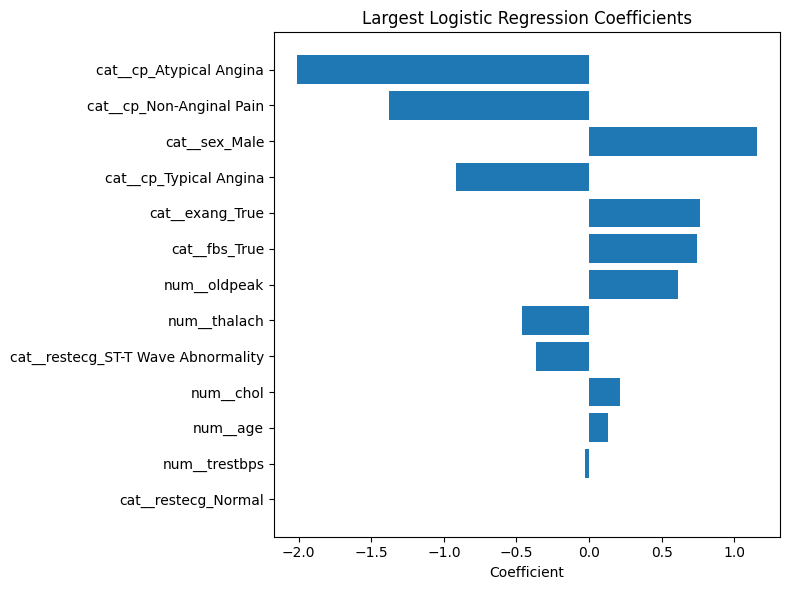

In [39]:
# Create bar chart of the logistic regression coefficients,
# sorted by decreasing magnitude.
plt.figure(figsize = (8,6))

plt.barh(coef_df["Feature"], coef_df["Coefficient"])

plt.xlabel("Coefficient")
plt.title("Largest Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In the Bivariate EDA section, we noted that all categorical variables (except restecg) had large differences in heart disease rates among their classes. We also noted that these differences could make these variables important predictors. This observation is borne out in the regression coefficients: the 6 largest coefficients (in terms of absolute value) are all derived from categorical features. Furthermore, 3 out of the top 4 coefficients are derived from a single variable: cp (chest pain type).

### Odds ratio interpretations

Odds ratios are calculated simply by exponentiating each logistic regression coefficient. For categorical variables, the odds ratio compares the odds of heart disease for the specified category to the reference category, holding the other model predictors constant.

We focus on the six largest absolute coefficients (all categorical).

1.  <u>cat__cp_Atypical Angina</u>: People with Atypical Angina have **lower** odds of having heart disease than those with Asymptomatic chest pain (which is the reference category). Holding all other variables constant, the odds of having heart disease are 0.13 times that of those with Asymptomatic chest pain.
2.  <u>cat__cp_Non-Anginal Pain</u>: Non-Anginal Pain have **lower** odds of having heart disease than those with Asymptomatic chest pain. Holding all other variables constant, the odds of having heart disease are 0.25 times that of those with Asymptomatic chest pain.
3.  <u>cat__sex_Male</u>: Males have **higher** odds of having heart disease than females. Holding all other variables constant, the odds of having heart disease are 3.18 times that of females (the reference category).
4.  <u>cat__cp_Typical Angina</u>: People with Typical Angina have **lower** odds of having heart disease than those with Asymptomatic chest pain. Holding all other variables constant, the odds of having heart disease are 0.40 times that of those with Asymptomatic chest pain.
5.  <u>cat__exang_True</u>: People with exercise-induced angina have **higher** odds of having heart disease than those without (the reference category). Holding all other variables constant, the odds of having heart disease are 2.14 times that of those without exercise-induced angina.
6.  <u>cat__fbs_True</u>: People with fasting blood sugar above 120 mg/dl have **higher** odds of having heart disease than those without (the reference category). Holding all other variables constant, the odds of having heart disease are 2.09 times that of those with blood sugar below the 120 mg/dl threshold.


# Model Performance on Test Data

The test set was held out from model selection and hyperparameter tuning. We will now use it as a simulation of the baseline logistic regression model's real-world performance.

We will begin by using the default decision threshold of 0.5, meaning that an observation will be classified as a positive case if its probability is at least 50%.

We will also create a bootstrap sampling distribution to estimate the 95% confidence intervals of recall and precision.

In [40]:
# Use baseline logistic regression model to make predictions on test data.
probs_logistic = logistic_pipeline.predict_proba(X_test)[:,1]

# Set decision threshold to 0.5.
# NOTE: This is the default decision threshold, but we are explicitly defining it
# now because we will change it later.
threshold = 0.5

pred = (probs_logistic >= threshold).astype(int)

# Create bootstrap confidence interval.
n_bootstraps = 1000
rng = np.random.default_rng(seed)

boot_recalls = []
boot_precisions = []

y_test_arr = y_test.reset_index(drop = True)
pred_arr = pd.Series(pred).reset_index(drop = True)

for i in range(n_bootstraps):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))  # sampling with replacement
    y_boot = y_test_arr[idx]
    pred_boot = pred_arr[idx]
    
    boot_recalls.append(recall_score(y_boot, pred_boot))
    boot_precisions.append(precision_score(y_boot, pred_boot))

recall_ci = np.percentile(boot_recalls, [2.5, 97.5])
precision_ci = np.percentile(boot_precisions, [2.5, 97.5])

print("\nTest Set Results (Decision Threshold = 0.5)")
print("----------------")
print(f"Recall: {recall_score(y_test, pred):.3f}, 95% CI [{recall_ci[0]:.3f}, {recall_ci[1]:.3f}]")
print(f"Precision: {precision_score(y_test, pred):.3f}, 95% CI [{precision_ci[0]:.3f}, {precision_ci[1]:.3f}]")


Test Set Results (Decision Threshold = 0.5)
----------------
Recall: 0.824, 95% CI [0.766, 0.879]
Precision: 0.803, 95% CI [0.737, 0.863]


[Text(0, 0.5, 'No Heart Disease'), Text(0, 1.5, 'Heart Disease')]

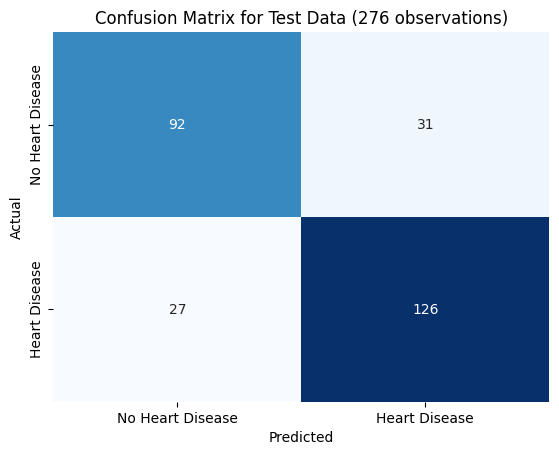

In [41]:
# Confusion matrix for test data predictions.
cm = confusion_matrix(y_test, pred)

# Visualization of confusion matrix
ax = plt.subplot()
sns.heatmap(cm, annot = True, fmt = 'g',
            cbar = False, cmap = 'Blues',
            ax = ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix for Test Data ({y_test.shape[0]} observations)')
ax.xaxis.set_ticklabels(['No Heart Disease', 'Heart Disease'])
ax.yaxis.set_ticklabels(['No Heart Disease', 'Heart Disease'])

The baseline logistic regression model has a recall of 82.4% on the test data, detecting 126 out of 153 cases of heart disease. The precision is 80.3%, meaning that, when the model predicted heart disease, it was correct 80.3% of the time.

Our bootstrap sampling distribution yields 95% confidence intervals of (0.766, 0.879) for recall and (0.737, 0.863) for precision. Although recall is slightly higher, the confidence intervals have considerable overlap.

**Overall, with a decision threshold of 0.5, the model was relatively balanced between recall and precision**. 

## Decision Threshold

As noted earlier, recall is our primary target metric, and precision is our secondary metric. The reason we chose recall as our primary target metric is because of how important it is to identify true cases of heart disease. Missing a true case of heart disease can have severe consequences, so we assume that, in a clinical setting, missing a true case of heart disease is generally worse than recommending additional testing for someone who ultimately does not have heart disease. It may be worth it to use a "safer" (i.e. lower) decision threshold to achieve higher recall at the expense of lower precision. 

Instead of selecting a final threshold, we examine the relationship between the threshold, recall, and precision. The operating threshold should ultimately be determined by consulting with stakeholders to define acceptable false-negative and false-positive costs.

In [42]:
# Obtain validation probabilities from the outer cross-validation folds (i.e. out-of-fold predicted probabilities).
oof_probs = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv = outer_cv,
    method = "predict_proba",
    n_jobs = -1
)[:, 1]

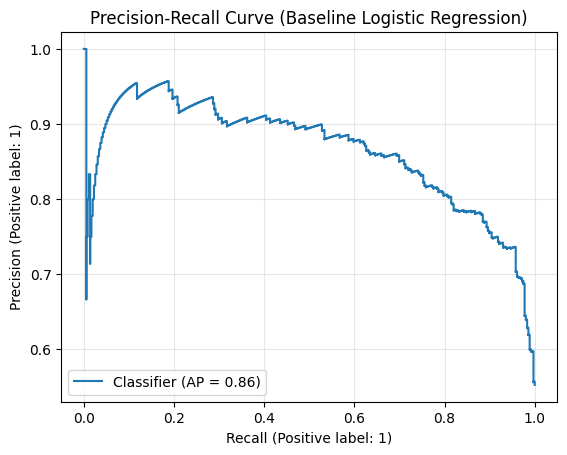

In [43]:
# Create the Precision-Recall curve
PrecisionRecallDisplay.from_predictions(
    y_train,
    oof_probs
)

plt.title("Precision-Recall Curve (Baseline Logistic Regression)")
plt.grid(alpha = 0.3)
plt.show()

The precision-recall curve, which plots the combinations of precision and recall at all decision thresholds, shows that this model can maintain precision above 60% at almost all levels of recall. Additionally, precision drops sharply once recall gets up to the mid- to upper- 90% range. This curve suggests that we can "push up" the recall via the decision threshold while maintaining respectable precision.

Next, we will plot recall-precision combinations at a selection of lower decision thresholds.

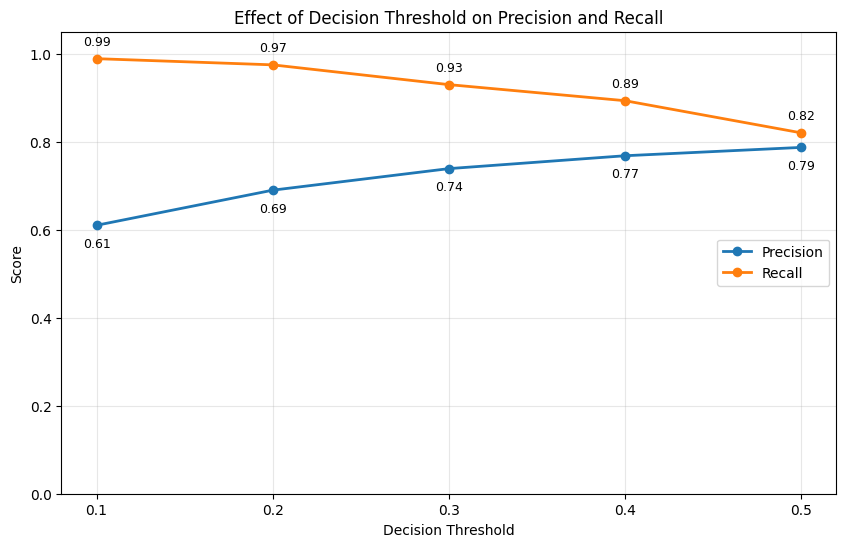

In [44]:
# Define a list of decision thresholds to evaluate.
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

# Calculate the precision and recall scores at each decision threshold.
results = []

for threshold in thresholds:

    pred = (oof_probs >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, pred),
        "Recall": recall_score(y_train, pred)
    })

threshold_results = pd.DataFrame(results)

# Plot the results in a line graph.
plt.figure(figsize = (10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker = "o",
    linewidth = 2,
    label = "Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker = "o",
    linewidth = 2,
    label = "Recall"
)

# Annotate each point on the graph.
for _, row in threshold_results.iterrows():
    plt.text(
        row["Threshold"],
        row["Precision"] - 0.05,
        f"{row['Precision']:.2f}",
        ha = "center",
        fontsize = 9
    )

    plt.text(
        row["Threshold"],
        row["Recall"] + 0.03,
        f"{row['Recall']:.2f}",
        ha = "center",
        fontsize = 9
    )

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Effect of Decision Threshold on Precision and Recall")
plt.xticks(thresholds)
plt.ylim(0, 1.05)
plt.grid(alpha = 0.3)
plt.legend(loc = 'center right')

plt.show()

Ultimately, an acceptable decision threshold will need to be based on providers' willingness to accept false positives. But for this data, at the most conservative decision threshold of 10%, we can maintain precision above 60%, even while pushing recall all the way up to 99%.

Ultimately, the best decision threshold will depend on the clinical consequences and resource costs associated with the recall-precision tradeoff. **We therefore do not recommend a specific threshold. In real-world usage, clinicians and other stakeholders will need to define the acceptable performance requirements in order to select an appropriate decision threshold**.

### A Potential Framework: Cost-based Decision Threshold Selection

Although we are refraining from making a decision threshold recommendation in this document, we will model a potential framework that future analyses can use when working through this issue with stakeholders. 

One way of assessing the optimal decision threshold is to put fixed costs on false negatives and false positives. For example, let's say that, after consulting with stakeholders, we discover that failing to catch heart disease (false negative) is 5 times worse than referring a healthy patient for additional testing (false positive). So the total expected cost will be:

<div align="center"><i>Total Expected Cost = 5*(Number of false negatives) + Number of false positives<i></div>
<p></p>

Then, we can calculate the total expected cost at each decision threshold. The optimal threshold will be that which minimizes the total expected cost.

We will graph a selection of cost ratios (false negatives relative to false positives) to observe the changes in total expected cost and the optimal decision threshold.

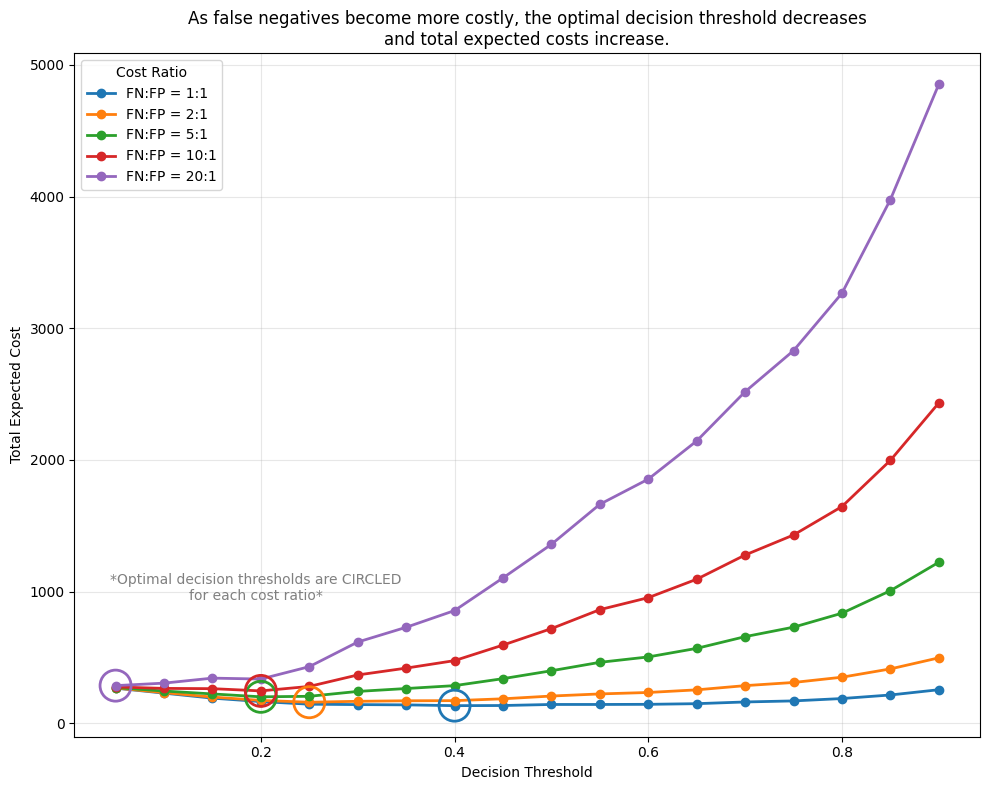

In [45]:
thresholds = np.arange(0.05, 0.95, 0.05)

# Define cost ratio candidates (cost of a false negative relative to a false positive)
cost_ratios = [1, 2, 5, 10, 20]

all_results = []

# For each cost ratio, make predictions, evaluate true and false predictions, and calculate costs
# for every decision threshold.
for ratio in cost_ratios:
    for t in thresholds:
        pred = (oof_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
        total_cost = fn * ratio + fp * 1
        all_results.append({"Threshold": t, "Cost": total_cost, "Cost Ratio": f"{ratio}:1"})

cost_df = pd.DataFrame(all_results)

# Define custom ratio order.
# NOTE: This is helpful for presentation purposes because the cost ratios 
# ultimately are presented as categorical variables (and for example, in categorical variables,
# 10, by default, is alphabetically before 2).
ratio_order = [f"{ratio}:1" for ratio in cost_ratios]

cost_df["Cost Ratio"] = pd.Categorical(
    cost_df["Cost Ratio"],
    categories = ratio_order,
    ordered = True
)

# Create line graph of total expected cost vs. decision threshold for each cost ratio.
plt.figure(figsize = (10, 8))

for ratio, group in cost_df.groupby("Cost Ratio", observed = True):
    line, = plt.plot(group["Threshold"], group["Cost"], marker = "o", linewidth = 2, label=f"FN:FP = {ratio}")

    # Circle the minimum-cost point for each line.
    min_row = group.loc[group["Cost"].idxmin()]

    plt.scatter(min_row["Threshold"], min_row["Cost"],
                s = 500, facecolors = "none", edgecolors = line.get_color(),
                linewidths = 2, zorder = 5)
    
plt.xlabel("Decision Threshold")
plt.ylabel("Total Expected Cost")
plt.title("As false negatives become more costly, the optimal decision threshold decreases\nand total expected costs increase.")
plt.legend(title = "Cost Ratio")
plt.text(0.2, .2, "*Optimal decision thresholds are CIRCLED\nfor each cost ratio*", 
         ha = 'center', 
         transform = plt.gca().transAxes,
         color = 'gray')
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

We will also create a table of the optimal decision threshold for each cost ratio (corresponding to the circles in the above graph), along with their associated recalls and precisions.

In [46]:
# Create dataframe of optimal thresholds for each cost ratio.
# This dataframe corresponds to the circles in the above graph.
optimal = []

for ratio, group in cost_df.groupby("Cost Ratio", observed = True):
    min_row = group.loc[group["Cost"].idxmin()]
    optimal.append({'Cost Ratio (FN:FP)': min_row['Cost Ratio'],
                      'Optimal Decision Threshold': min_row['Threshold']})

optimal_df = pd.DataFrame(optimal)

# Compute recall and precision scores corresponding to optimal decision thresholds.
optimal_df["Recall"] = optimal_df['Optimal Decision Threshold'].apply(
    lambda t: recall_score(y_train, (oof_probs >= t).astype(int)).round(3)
)
optimal_df["Precision"] = optimal_df['Optimal Decision Threshold'].apply(
    lambda t: precision_score(y_train, (oof_probs >= t).astype(int)).round(3)
)

optimal_df

,Cost Ratio (FN:FP),Optimal Decision Threshold,Recall,Precision
0,1:1,0.40,0.893,0.768
1,2:1,0.25,0.958,0.724
2,5:1,0.20,0.975,0.690
3,10:1,0.20,0.975,0.690
4,20:1,0.05,0.997,0.572


From the preceding graph and table, we can observe several trends:

As false negatives become more costly relative to false positives...
- Total expected cost increases.
- The optimal decision threshold decreases.
  - Consequently, recall increases and precision decreases.

It is also worth noting that the cost ratio lines in the graph are fairly close together for the lower decision thresholds, illustrating that total expected costs are fairly similar for lower decision thresholds, regardless of the cost ratio. The lines only start to diverge once decision thresholds go above 0.30 or so. **This suggests that the total expected costs are fairly insensitive to cost ratios at lower decision thresholds, so a lower decision threshold could be a safe choice if stakeholders are not able to confidently pinpoint an exact cost ratio**.

---
This cost-based decision threshold framework is not without limitations. First, "costs" are defined broadly and only in terms of strictly quantifiable outcomes. They do not account for impacts that are hard to quantify, such as moral concerns. And they only account for outcome-based costs, neglecting, for example, to account for the procedural costs of referring patients for testing. Second, this framework does not account for the benefits of correct decisions that could offset the costs (e.g. grant money for achieving benchmark recall and precision values).

Due to these limitations, this framework should be viewed as a starting point that future research can build on rather than a conclusive framework.

## Limitations

One of the chief concerns with this dataset is that several categorical subgroups have very few observations. Since the training dataset only has about 600 observations, the model might not have enough data to learn from each subgroup. The risk with this is that the model could be less reliable for subgroups with fewer observations.

For example, the variable sex only has 134 females in the training set. We will compare the model's performance on male-only vs. female-only test sets.

In [47]:
# Create separate test sets for males and females.
male_test = X_test[X_test['sex'] == 'Male']
female_test = X_test[X_test['sex'] == 'Female']

# Get the indices of the male rows.
male_indices = male_test.index

# Create response test set for females. 
y_test_female = y_test.drop(male_indices)

# Get the indices of the female rows.
female_indices = female_test.index

# Create response test set for males.
y_test_male = y_test.drop(female_indices)

# Set decision threshold.
threshold = 0.5

# Compute predictions for male participants.
probs_male = logistic_pipeline.predict_proba(male_test)[:,1]
pred_male = (probs_male >= threshold).astype(int)

# Compute predictions for female participants.
probs_female = logistic_pipeline.predict_proba(female_test)[:,1]
pred_female = (probs_female >= threshold).astype(int)

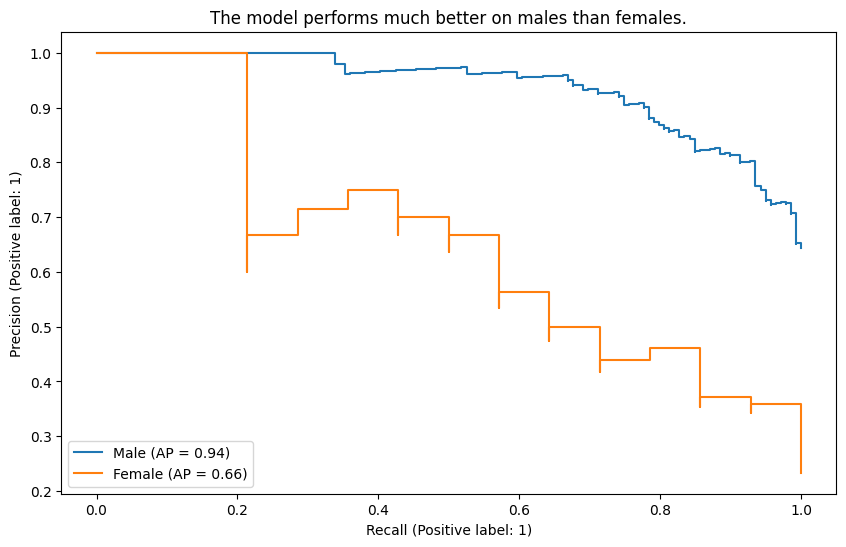

In [48]:
# Plot precision-recall curves for male-only and female-only predictions.
fig, ax = plt.subplots(figsize = (10, 6))

PrecisionRecallDisplay.from_predictions(y_test_male, probs_male, name = "Male", ax = ax)
PrecisionRecallDisplay.from_predictions(y_test_female, probs_female, name = "Female", ax = ax)

plt.title("The model performs much better on males than females.")
plt.show()

If we apply the model to male-only and female-only versions of the test data, the precision-recall curves show that the model performs considerably better for male participants than females. For example, at most levels of recall, the male curve has better precision by at least 20 percentage points.

---

We will also compare precision and recall scores (including bootstrap 95% confidence intervals) at the default 50% decision threshold.

In [49]:
# Create bootstrap confidence interval for male-only test set.
n_bootstraps = 1000
rng = np.random.default_rng(seed)

boot_recalls_male = []
boot_precisions_male = []

y_test_arr_male = y_test_male.reset_index(drop = True)
pred_arr_male = pd.Series(pred_male).reset_index(drop = True)

for i in range(n_bootstraps):
    idx = rng.integers(0, len(y_test_arr_male), len(y_test_arr_male))  # sampling with replacement
    y_boot_male = y_test_arr_male[idx]
    pred_boot_male = pred_arr_male[idx]
    
    boot_recalls_male.append(recall_score(y_boot_male, pred_boot_male))
    boot_precisions_male.append(precision_score(y_boot_male, pred_boot_male))

recall_ci_male = np.percentile(boot_recalls_male, [2.5, 97.5])
precision_ci_male = np.percentile(boot_precisions_male, [2.5, 97.5])

print("Model Performance on MALE-only Test Set (Decision Threshold = 0.5)")
print("-------------")
print(f"Recall: {recall_score(y_test_male, pred_male):.3f}, 95% CI [{recall_ci_male[0]:.3f}, {recall_ci_male[1]:.3f}]")
print(f"Precision: {precision_score(y_test_male, pred_male):.3f}, 95% CI [{precision_ci_male[0]:.3f}, {precision_ci_male[1]:.3f}]")

Model Performance on MALE-only Test Set (Decision Threshold = 0.5)
-------------
Recall: 0.849, 95% CI [0.788, 0.905]
Precision: 0.831, 95% CI [0.769, 0.891]


In [50]:
# Create bootstrap confidence interval for female-only test set.
n_bootstraps = 1000
rng = np.random.default_rng(seed)

boot_recalls_female = []
boot_precisions_female = []

y_test_arr_female = y_test_female.reset_index(drop = True)
pred_arr_female = pd.Series(pred_female).reset_index(drop = True) 

for i in range(n_bootstraps):
    idx = rng.integers(0, len(y_test_arr_female), len(y_test_arr_female))  # sampling with replacement
    y_boot_female = y_test_arr_female[idx]
    pred_boot_female = pred_arr_female[idx]
    
    boot_recalls_female.append(recall_score(y_boot_female, pred_boot_female))
    boot_precisions_female.append(precision_score(y_boot_female, pred_boot_female))

recall_ci_female = np.percentile(boot_recalls_female, [2.5, 97.5])
precision_ci_female = np.percentile(boot_precisions_female, [2.5, 97.5])

print("Model Performance on FEMALE-only Test Set (Decision Threshold = 0.5)")
print("-------------")
print(f"Recall: {recall_score(y_test_female, pred_female):.3f}, 95% CI [{recall_ci_female[0]:.3f}, {recall_ci_female[1]:.3f}]")
print(f"Precision: {precision_score(y_test_female, pred_female):.3f}, 95% CI [{precision_ci_female[0]:.3f}, {precision_ci_female[1]:.3f}]")

Model Performance on FEMALE-only Test Set (Decision Threshold = 0.5)
-------------
Recall: 0.571, 95% CI [0.300, 0.833]
Precision: 0.533, 95% CI [0.278, 0.800]


At the default decision threshold of 0.5, the model shows about a 28-percentage-point advantage for males on recall and a 30-percentage-point advantage on precision. Taking the 95% confidence intervals into account reveals even more severe limitations. The male-only recall and precision confidence intervals compare favorably to that of the entire test set, but the female-only confidence intervals are very wide.

The female-only confidence intervals are both over 50 percentage-points wide: the recall interval ranges from 30% to 83.3%, and the precision interval ranges from 27.8% to 80%. Such high variability means that the estimates are too imprecise to support reliable conclusions about female patients.

---

As it stands, the model performs much better on male participants. The current data do not allow us to determine whether the disparity is caused primarily by the smaller number of female observations, differences in the relationship between the predictors and response variable, differences in data quality, or some combination of these factors. Collecting more data would help us tease apart these factors. 

Given that there are large class imbalances for all categorical features, however, there are likely to be similar issues for the other variables. This is a problem in a clinical setting because the model might not perform as well for people with characteristics that do not have many observations. For example, health care providers will not be able to rely on this model as confidently for patients who are female or have a high fasting blood sugar (fbs = True). Future analyses should also evaluate performance across relevant patient subgroups rather than relying solely on overall metrics.

## Calibration

Finally, we will briefly assess the calibration of the model probabilities. Since decision thresholds will play such a large role in the model's deployment, we need to be able to have confidence in the model's predicted probabilities. Put simply, if a model predicts a 30% chance of heart disease for a given patient, then about 30% of similar patients should have heart disease. 

We will assess calibration by examining its calibration curve.

<Figure size 600x600 with 0 Axes>

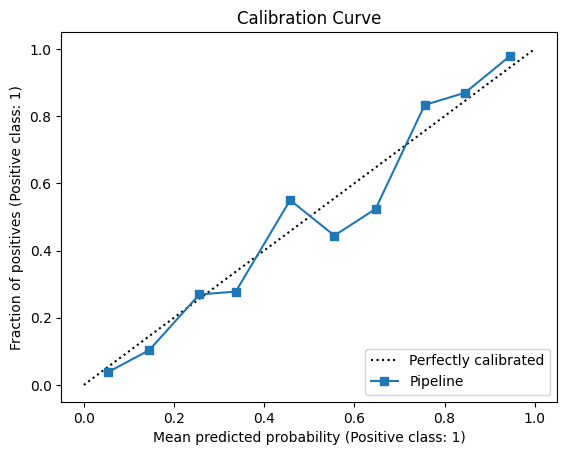

In [51]:
# Create calibration curve
plt.figure(figsize = (6,6))

CalibrationDisplay.from_estimator(
    logistic_pipeline,
    X_test,
    y_test,
    n_bins = 10
)

plt.title("Calibration Curve")
plt.show()

The calibration curve suggests that the model's probabilities are reasonably aligned with observed outcomes at the high and low probability ranges but are less consistent in the middle of the probability range. 

Given the relatively small test set, this assessment should be considered preliminary. In future analyses, calibration should be evaluated more extensively.

# Conclusion

This analysis evaluated logistic regression and random forest models for predicting heart disease using 920 observations from the UCI Heart Disease dataset. Recall was selected as the primary metric because the analysis prioritized identifying patients with heart disease, while precision and ROC-AUC provided complementary measures of predictive performance.

Hyperparameter tuning did not find statistically significant differences in recall performance. Although the tuned models had modest increases in mean validation recall, Friedman's test did not find evidence of a statistically significant difference. The tuned models also did not consistently improve the secondary metrics. Additionally, the logistic regression models had smaller train-validation recall gaps than the random forest models, suggesting lower risks of overfitting.

Based on these results, we preferred the baseline logistic regression for the current analysis. Its performance is competitive with the tuned models and does not require evidence that additional hyperparameter complexity provides a meaningful benefit.

The analysis also identified important limitations. Model performance was substantially worse for female patients than for male patients at the default threshold, suggesting that the available data do not provide equally strong information across subgroups. The model's probability calibration was also imperfect, and the appropriate decision threshold cannot be determined from model performance alone. We provided an initial cost-based framework for choosing an optimal decision threshold, but the final decision threshold will need to reflect the clinical consequences and acceptable tradeoffs between missed heart disease cases and false-positive referrals.

Therefore, the current model should be viewed as a prototype rather than a production-ready model. Future work should include collecting additional representative data, evaluating performance across relevant patient subgroups, establishing stakeholder-defined performance requirements, and reassessing model selection and calibration after the expanded dataset becomes available.

# Recommendations

The next steps for this analysis should include the following:

- <u>Define minimum acceptable standards for recall and precision with stakeholders and false classification costs</u>. Using the default decision threshold of 0.5, our model performed in the 80% range for both recall and precision. We also demonstrated that varying the decision threshold can affect recall and precision. Future analyses should consult with clinicians and other stakeholders to define recall and precision goals and costs associated with false negatives and false positives so that an optimal decision threshold can be chosen.
- <u>Collect additional representative data, particularly for underrepresented subgroups</u>. We demonstrated that the model performs substantially worse for female patients than for male patients. Additional data collection and analyses should be done to determine whether similar disparities hold for other variables and whether the disparities are due to limited subgroup sample sizes, differences in predictor-outcome relationships, or other sources of bias.
- <u>Reassess model selection after expanding the dataset</u>. Hyperparameter tuning did not produce sufficiently strong evidence of improvement over the baseline logistic regression under the current sample size. With more representative data, model comparisons can be repeated to determine whether other models can improve over the baseline logistic regression.
- <u> Further evaluate probability calibration</u>. Since decision thresholds are based on probabilities, stakeholders need to be able to trust the probability predictions. Future analyses should thoroughly investigate and improve model calibration.

---

# References

Brownlee, J. (2021, November 20). Nested Cross-Validation for Machine Learning with Python. Machine Learning Mastery. https://machinelearningmastery.com/nested-cross-validation-for-machine-learning-with-python/

Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/45/heart+disease

Mass General Brigham. (n.d.). Tachycardia: Symptoms & treatment. Mass General Brigham. https://www.massgeneralbrigham.org/en/patient-care/services-and-specialties/heart/conditions/tachycardia

Rainio, O., Teuho, J., & Klén, R. (2024). Evaluation metrics and statistical tests for machine learning. Scientific Reports, 14, 6086. https://doi.org/10.1038/s41598-024-56706-x

Richards, L. (2022, November 17). Cholesterol over 500: How to lower it and what the numbers mean. Medical News Today. https://www.medicalnewstoday.com/articles/cholesterol-over-500

Things you need to know about blood pressure and hypertension. (2006). Canadian Journal of Cardiology, 22(7), 601–602. https://pmc.ncbi.nlm.nih.gov/articles/PMC2560868/

Vatcheva, K. P., Lee, M., McCormick, J. B., & Rahbar, M. H. (2016). Multicollinearity in regression analyses conducted in epidemiologic studies. Epidemiology (Sunnyvale), 6(2), 227. https://doi.org/10.4172/2161-1165.1000227

Yazdani, A., Varathan, K. D., Chiam, Y. K., Malik, A. W., & Wan Ahmad, W. A. (2021). A novel approach for heart disease prediction using strength scores with significant predictors. BMC Medical Informatics and Decision Making, 21, 194. https://doi.org/10.1186/s12911-021-01527-5